# Processing MITGCM data for the Temporal Scale Analysis along a CalCOFI transect 

**Purpose**: Code for producing data for temporal decorrelation scale analysis. Here, we will generate maps of temperature, salinity, and velocity as a function of time, depth, and distance off the coast of Point Conception along the CalCOFI line 80.0. 

**Luke Colosi | lcolosi@ucsd.edu**

Import python libraries

In [ ]:
import sys
import numpy as np
import xarray as xr
from xmitgcm import open_mdsdataset
from geopy.distance import geodesic
import matplotlib.pyplot as plt 
import xgcm

: 

Set data analysis parameters

In [ ]:
# Model parameters 
delta_t = 150  # Time steps of the raw model run (by raw, I mean the time increments that the model is ran at, not time increments that the diagnostics are output at). Units: seconds

# Set time and space parameters  
lat_bnds  = [33.0, 35.0]                                          # Specifies the latitude bounds for the region to analyze
lon_bnds  = [237.0, 240.0]                                        # Specifies the longitude bounds for the region to analyze
encoding  = {'time': {'units': 'seconds since 2015-12-01 2:00'}}  # Specifies the start time of the model run

# Set path to project directory
PATH_GRID   = '/data/SO2/SWOT/GRID/BIN/'                                     # Space and time grid of the model 
PATH_OUTPUT = '/data/SO2/SWOT/MARA/RUN4_LY/DIAGS_HRLY/'                      # Diagnostics of the model
PATH_nc     = '/data/SO3/lcolosi/mitgcm/SWOT_MARA_RUN4_LY/spatial/transect/' # Directory to save netCDFs 
file_dim    = '3D'                                                           # Set the dimension of the data (to include the depth or not where 3D is T,S,drhodr,vel and 2D is etan)

: 

Load the grid and diagnostics data into a python structure. The diagnostics that we will be looking at include: 

1. **Potential Temperature** $\theta$: $^\circ C$
2. **Salinity** $S$: $g/kg$
3. **Stratification** $\frac{d\sigma}{dz}$: $kg/m^4$
4. **Zonal, meridional, and vertical velocity components**  $\textbf{u} = (u,v,w)$: $m/s$  

In [3]:
# Create dataset 
ds = open_mdsdataset(
    PATH_OUTPUT,                    # File path where the model output data is stored (.data and .meta files)
    PATH_GRID,                      # File path to the grid data of the model 
    iters='all',                    # Specifies which iteration of the data to load
    delta_t=delta_t, 
    ignore_unknown_vars=False,      # Specifies whether to ignore any unknown variables that may appear in the dataset
    prefix=['diags_' + file_dim],   # List of prefixes to filter the variables in the dataset
    ref_date="2015-01-01 02:00:00", # Specifies the starting point of the simulation time (which may include the spin up time before diagnostics are output)
    geometry='sphericalpolar'       # Specifies the  grid's geometry is spherical-polar. 
)

# Convert all variables and coordinates in the dataset to little-endian (the format how multi-byte values are stored into memory)

#--- Variables ---#
for var in ds.data_vars:
    if ds[var].dtype.byteorder == '>' or (ds[var].dtype.byteorder == '=' and sys.byteorder == "big"):  # Check if big-endian
        ds[var] = ds[var].astype(ds[var].dtype.newbyteorder('<'))

#--- Coordinates ---# 
for coord in ds.coords:
    if ds[coord].dtype.byteorder == '>'or (ds[coord].dtype.byteorder == '=' and sys.byteorder == "big"):  # Check if big-endian
        ds[coord] = ds[coord].astype(ds[coord].dtype.newbyteorder('<'))

Interpolate the velocity grids on the (XC, YC) grid


In [4]:
# Define the grid object (says which dimensions are 'center' and which are 'left' (or 'right')
grid = xgcm.Grid(ds, coords={'X': {'center': 'XC', 'left': 'XG'}, 
                             'Y': {'center': 'YC', 'left': 'YG'}, 
                             'Z': {'center': 'Z',  'left': 'Zl'}}, 
                 periodic=False, boundary='extend') 

# Interpolate to the centers
ds['U_center'] = grid.interp(ds.UVEL, axis='X') # Interpolate from the X-face to the center
ds['V_center'] = grid.interp(ds.VVEL, axis='Y') # Interpolate from the Y-face to the center
ds['W_center'] = grid.interp(ds.WVEL, axis='Z') # Interpolate from the Z-face (Zl) to the center

/home/lcolosi/miniconda3/envs/ccs_scale/lib/python3.12/site-packages/xgcm/grid_ufunc.py:832: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  out_dim: grid._ds.dims[out_dim] for arg in out_core_dims for out_dim in arg
/home/lcolosi/miniconda3/envs/ccs_scale/lib/python3.12/site-packages/xgcm/grid_ufunc.py:832: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  out_dim: grid._ds.dims[out_dim] for arg in out_core_dims for out_dim in arg
/home/lcolosi/miniconda3/envs/ccs_scale/lib/python3.12/site-packages/xgcm/grid_ufunc.py:832: FutureWarning: The return type of `Dataset.dims` will be changed to retur

Set CalCOFI station locations

In [5]:
# Manually read in station locations
calcofi_lat = np.array([34.46667, 34.45, 34.31667, 34.15, 33.81667, 33.48333, 33.15, 32.81667])
calcofi_lon = np.array([-120.48906, -120.5239, -120.80245, -121.15, -121.84304, -122.53335, -123.22099, -123.90599])

# Sort stations from shore outward
idx = np.argsort(calcofi_lon)
calcofi_lon = calcofi_lon[idx]
calcofi_lat = calcofi_lat[idx] 

Compute cumulative diastance along line 80.0 

In [6]:
# Initialize array 
dist = np.zeros(len(calcofi_lon))

# Loop through stations 
for i in range(1,len(calcofi_lon)): 

    # Define i and i + 1 points along transect
    pt1 = (calcofi_lat[i-1], calcofi_lon[i-1])
    pt2 = (calcofi_lat[i],   calcofi_lon[i])

    # Compute distance in kilometers along transect
    dist[i] = dist[i-1] + geodesic(pt1, pt2).km

Create a denser distance axis (near the resolution of the model grid)

In [7]:
# Set spacing (units: kilometer)
dr = 2 

# Generate a denser array 
dist_dense = np.arange(0, dist[-1], dr)

# Interpolate lat and longitude along this denser line
calcofi_lat_dense = np.interp(dist_dense, dist, calcofi_lat)
calcofi_lon_dense = np.interp(dist_dense, dist, calcofi_lon)

# Convert the calcofi longitude to span from 0 to 360 
calcofi_lon_dense = (calcofi_lon_dense + 360) % 360

Interpolate model onto transect 

In [8]:
# Apply land mask using hFacC (wet-dry mask) to avoid blending of zeros (fill value) near the ocean bottom
theta_masked = ds['THETA'].where(ds['hFacC'] > 0)
salt_masked  = ds['SALT'].where(ds['hFacC'] > 0)
uvel_masked  = ds['U_center'].where(ds['hFacC'] > 0)
vvel_masked  = ds['V_center'].where(ds['hFacC'] > 0)

# Define your transect DataArrays
lat_da = xr.DataArray(calcofi_lat_dense, dims="distance")
lon_da = xr.DataArray(calcofi_lon_dense, dims="distance")

# Interpolate on transect
theta = theta_masked.interp(YC=lat_da, XC=lon_da)
salt = salt_masked.interp(YC=lat_da, XC=lon_da)
uvel = uvel_masked.interp(YC=lat_da, XC=lon_da)
vvel = vvel_masked.interp(YC=lat_da, XC=lon_da)

Assign distance coordinate

In [9]:
theta = theta.assign_coords(
    distance=("distance", dist_dense)
)

salt = salt.assign_coords(
    distance=("distance", dist_dense)
)

uvel = uvel.assign_coords(
    distance=("distance", dist_dense)
)

vvel = vvel.assign_coords(
    distance=("distance", dist_dense)
)

Create dataset for land mask 

In [10]:
# Define wet-dry array for the transect (e.g., 1 for ocean, 0 for land) and depth array for the transect
hfac = theta['hFacC']
depth = theta['Z']

# Set boolean wet mask
wet = hfac > 0.99 #0.99

# Count number of wet cells per column
bottom_index = wet.sum(dim='Z') - 1

# Prevent negative indices (in case of full land columns)
bottom_index = bottom_index.clip(min=0)

# Set bottom depth using the bottom index
bottom_depth = depth.isel(Z=bottom_index)

# Create a new dataset to store the ocean depth data
bottom_ds = xr.Dataset(
    data_vars=dict(
        bottom_depth=('distance', bottom_depth.values)
    ),
    coords=dict(
        distance=theta.coords['distance'].values
    ),
    attrs=dict(
        description="Ocean bottom depth derived from hFacC",
        units="meters"
    )
)

Plot to see how things look 

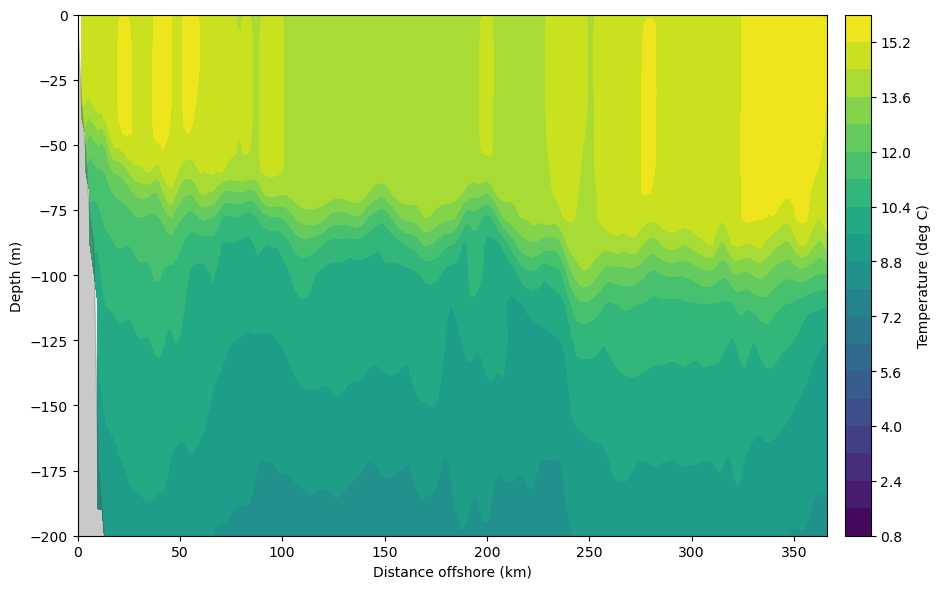

In [11]:
# Set plotting parameters
field = theta.isel(time=0)
depth = theta.coords['Z'].values
distance = theta.coords['distance'].values

# Create figure
fig, ax = plt.subplots(figsize=(10,6))

# Plot a single time frame of the transect along line 80 
cf = ax.contourf(distance[::-1], depth, field, levels=20)

# Plot the ocean bottom land mask
ax.fill_between(theta['distance'][::-1], bottom_depth,depth.min(),color='0.3', alpha=0.3)

# Set figure attributes 
ax.set_xlabel('Distance offshore (km)')
ax.set_ylabel('Depth (m)')
ax.set_ylim(-200,0)

# Add shared colorbar
cbar = fig.colorbar(cf, ax=ax, location='right', pad=0.02)
cbar.set_label('Temperature (deg C)')

# Adjust layout before adding colorbar
plt.tight_layout()
plt.show()  

In [ ]:
P

Save data in netcdf files

In [ ]:
#---------------------------------# 
# --- Ocean Bottom ---- 
# --------------------------------# 
bottom_ds.to_netcdf(
    f"{PATH_nc}ocean_bottom_CCS4_transect_calCOFI_line80.nc",
    engine='netcdf4',                # Fastest NetCDF writer (writes NetCDF3)
    format='NETCDF4'           
)

#---------------------------------# 
# --- Sea State Variables ---- 
# --------------------------------# 

# Set the dictionary of variables to save
vars_to_save = {
    #'THETA': theta,
    #'SALT': salt,
    'UVEL': uvel,
    'VVEL': vvel
}

# Loop through each variable and save efficiently
for var_name, da in vars_to_save.items():
    
    # Chunk along time for faster write (adjust chunk size if needed)
    if 'time' in da.dims:
        da = da.chunk({'time': 1000})
    
    # Load into memory before saving (triggers computation)
    da = da.load()
    
    # Print status
    print(f"Saving {var_name}...")

    # Save to NetCDF file
    da.to_netcdf(
        f"{PATH_nc}{var_name}_CCS4_hrly_transect_calCOFI_line80.nc",
        engine='netcdf4',                # Fastest NetCDF writer (writes NetCDF3)
        format='NETCDF4',        # Simple + compatible format
        encoding=encoding            
    )